### 問題4.1



In [77]:
from thinkbayes import Suite

class Euro(Suite):

    def Likelihood(self, data, hypo):
        x = hypo
        if data == 'H':
            return x/100.0
        else:
            return 1 - x/100.0

In [78]:
class NoisyCoin(Suite):

    def __init__(self, hypos, y=0.0):
        
        super().__init__(hypos)
        self.y = y

    def Likelihood(self, data, hypo):

        p = hypo/100.0

        if data == 'H':
            return p*(1-self.y) + (1-p)*self.y
        else:
            return (1-p)*(1-self.y) + p*self.y

In [ ]:
posts = range(1,101)
suite = NoisyCoin(posts, y=0.1)
suite2 = Euro(posts)

print(suite.Items())
# ==========
# Prior
# ==========
xs, ps = zip(*suite.Items())
xs2, ps2 = zip(*suite2.Items())




dict_items([(1, 0.01), (2, 0.01), (3, 0.01), (4, 0.01), (5, 0.01), (6, 0.01), (7, 0.01), (8, 0.01), (9, 0.01), (10, 0.01), (11, 0.01), (12, 0.01), (13, 0.01), (14, 0.01), (15, 0.01), (16, 0.01), (17, 0.01), (18, 0.01), (19, 0.01), (20, 0.01), (21, 0.01), (22, 0.01), (23, 0.01), (24, 0.01), (25, 0.01), (26, 0.01), (27, 0.01), (28, 0.01), (29, 0.01), (30, 0.01), (31, 0.01), (32, 0.01), (33, 0.01), (34, 0.01), (35, 0.01), (36, 0.01), (37, 0.01), (38, 0.01), (39, 0.01), (40, 0.01), (41, 0.01), (42, 0.01), (43, 0.01), (44, 0.01), (45, 0.01), (46, 0.01), (47, 0.01), (48, 0.01), (49, 0.01), (50, 0.01), (51, 0.01), (52, 0.01), (53, 0.01), (54, 0.01), (55, 0.01), (56, 0.01), (57, 0.01), (58, 0.01), (59, 0.01), (60, 0.01), (61, 0.01), (62, 0.01), (63, 0.01), (64, 0.01), (65, 0.01), (66, 0.01), (67, 0.01), (68, 0.01), (69, 0.01), (70, 0.01), (71, 0.01), (72, 0.01), (73, 0.01), (74, 0.01), (75, 0.01), (76, 0.01), (77, 0.01), (78, 0.01), (79, 0.01), (80, 0.01), (81, 0.01), (82, 0.01), (83, 0.01), (

In [80]:
'''
for data in dataset:
    suite2.Update(data)

suite2.Items()

post2 = [v for k, v in suite2.Items()]
xs2 = [k for k, v in suite2.Items()]

print(suite2.Mean())

print(suite2.MaximumLikelihood())

'''


'\nfor data in dataset:\n    suite2.Update(data)\n\nsuite2.Items()\n\npost2 = [v for k, v in suite2.Items()]\nxs2 = [k for k, v in suite2.Items()]\n\nprint(suite2.Mean())\n\nprint(suite2.MaximumLikelihood())\n\n'

In [81]:
'''
for data in dataset:
    suite.Update(data)

suite.Items()

post = [v for k, v in suite.Items()]
xs = [k for k, v in suite.Items()]

print(suite.Mean())
print(suite.MaximumLikelihood())



print(post == post2)


for i, (a, b) in enumerate(zip(post, post2)):
    if a != b:
        print(i, a, b)
        break
'''

'\nfor data in dataset:\n    suite.Update(data)\n\nsuite.Items()\n\npost = [v for k, v in suite.Items()]\nxs = [k for k, v in suite.Items()]\n\nprint(suite.Mean())\nprint(suite.MaximumLikelihood())\n\n\n\nprint(post == post2)\n\n\nfor i, (a, b) in enumerate(zip(post, post2)):\n    if a != b:\n        print(i, a, b)\n        break\n'

In [110]:
dataset = ['H', 'L','H']

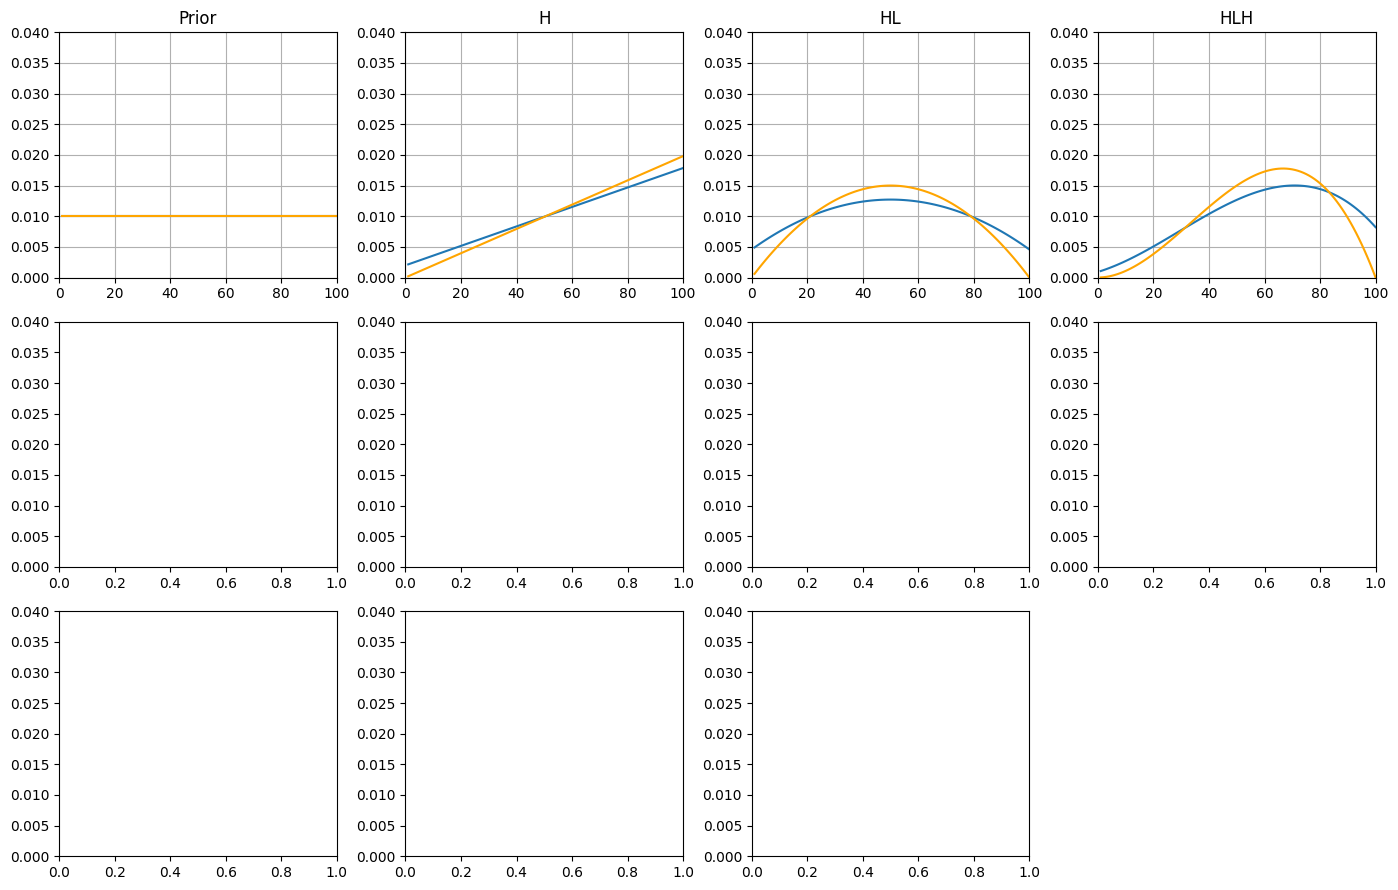

In [82]:
import matplotlib.pyplot as plt

# ------------------------------------
# 3行×4列（12枚）
# ------------------------------------
fig, axes = plt.subplots(3, 4, figsize=(14, 9))

axes = axes.flat

# ==========
# Prior
# ==========

axes[0].plot(xs, ps)
axes[0].plot(xs2, ps2, color="orange")
axes[0].set_title("Prior")
axes[0].set_xlim(0, 100)
axes[0].grid(True)

# ==========
# Updateごとに描画
# ==========
history = ""

for i, outcome in enumerate(dataset):

    history += outcome

    suite.Update(outcome)
    suite2.Update(outcome)

    xs, ps = zip(*suite.Items())
    xs2, ps2 = zip(*suite2.Items())

    axes[i+1].plot(xs, ps)
    axes[i+1].plot(xs2, ps2, color="orange")
    axes[i+1].set_title(history)
    axes[i+1].set_xlim(0, 100)
    axes[i+1].grid(True)

# 最後の1枚は空白
axes[-1].axis("off")

for ax in axes[:-1]:
    ax.set_ylim(0, 0.04)

plt.tight_layout()
plt.show()

### 4.2 Reddit




ThinkBayesの４章の練習問題：Redditとは、subredditと多くの専門グループからなるオンラインインフォメーションシステムである。利用者はredditorと呼ばれ、オンラインオ内容へのリンクやWebページを投稿する。他のredditorが、そのリンクについて投票して、高品質なリンクには、賛成票 (upvote) を、よくなかったり、無関係なリンクについては、反対票 (downvote) を投じる。redditorの中には信頼できる人とできない人がいるが、Redditではそれを考慮してない。課題はredditorが投票するときにそのredditorの信頼度に応じてリンクの品質の推測値が更新され、またredditorの信頼度の推定値がリンクの品質に応じて更新されるようなシステムを作り出すことである。一つのやり方は、リンクの品質を賛成票を生成する確率としてモデル化し、redditorの信頼度を高品質なものに対して賛成票を正しく投じる確率としてモデル化することである。Redditorとリンクに対するクラス定義と、redditorが投票するたびに両方のオブジェクトを更新する更新関数をかけ。

**登場人物**

* リンク（記事）
* Redditor（投票した人）

**リンク**

このリンクはどのくらい良い記事なのか知りたいが、品質は見えない

$ 品質 = Upvoteされる確率 $

例：　品質＝0.95 なら 95% ぐらいの人がいい記事と思う、品質=0.10なら、ほとんどの人がDownvoteする記事

リンクは未知の p を持っている


**Redditor**

この人はちゃんと判断できる人？

$ 信頼度 = 正しい判断をする確率 $

例：　信頼度＝0.95 なら、95%ぐらい正しい投票をする、信頼度=0.55なら、ほとんど運任せ

Redditorは未知の r を持っている

未知数が二つある







記事の良し悪しは、誰が投票したかによって判断し、人の信頼度は、どんな記事に投票したかによって判断する。



In [92]:
class Article1(Suite):

    def __init__(self, hypos, y=0.0):
        
        super().__init__(hypos)
        self.y = y

    def Likelihood(self, data, hypo):

        p = hypo/100.0

        if data == 'H':
            return p*(1-self.y) + (1-p)*self.y
        else:
            return (1-p)*(1-self.y) + p*self.y

In [93]:
class Reviewer1(Suite):

    def __init__(self, hypos, y=0.0):
        
        super().__init__(hypos)
        self.y = y

    def Likelihood(self, data, hypo):

        p = hypo/100.0

        if data == 'H':
            return p*(1-self.y) + (1-p)*self.y
        else:
            return (1-p)*(1-self.y) + p*self.y

In [94]:
posts = range(1,101)
suite = Article1(posts, y=0.1)
suite2 = Reviewer1(posts, y=0.9)


# ==========
# Prior
# ==========
xs, ps = zip(*suite.Items())
xs2, ps2 = zip(*suite2.Items())

dataset = ['H', 'L','H']


In [95]:
def MAP(suite):
    return max(suite.Items(), key=lambda kv: kv[1])[0]

def Mean(suite):
    return sum(x * p for x, p in suite.Items())

def Median(suite):
    total = 0
    for x, p in sorted(suite.Items()):
        total += p
        if total >= 0.5:
            return x

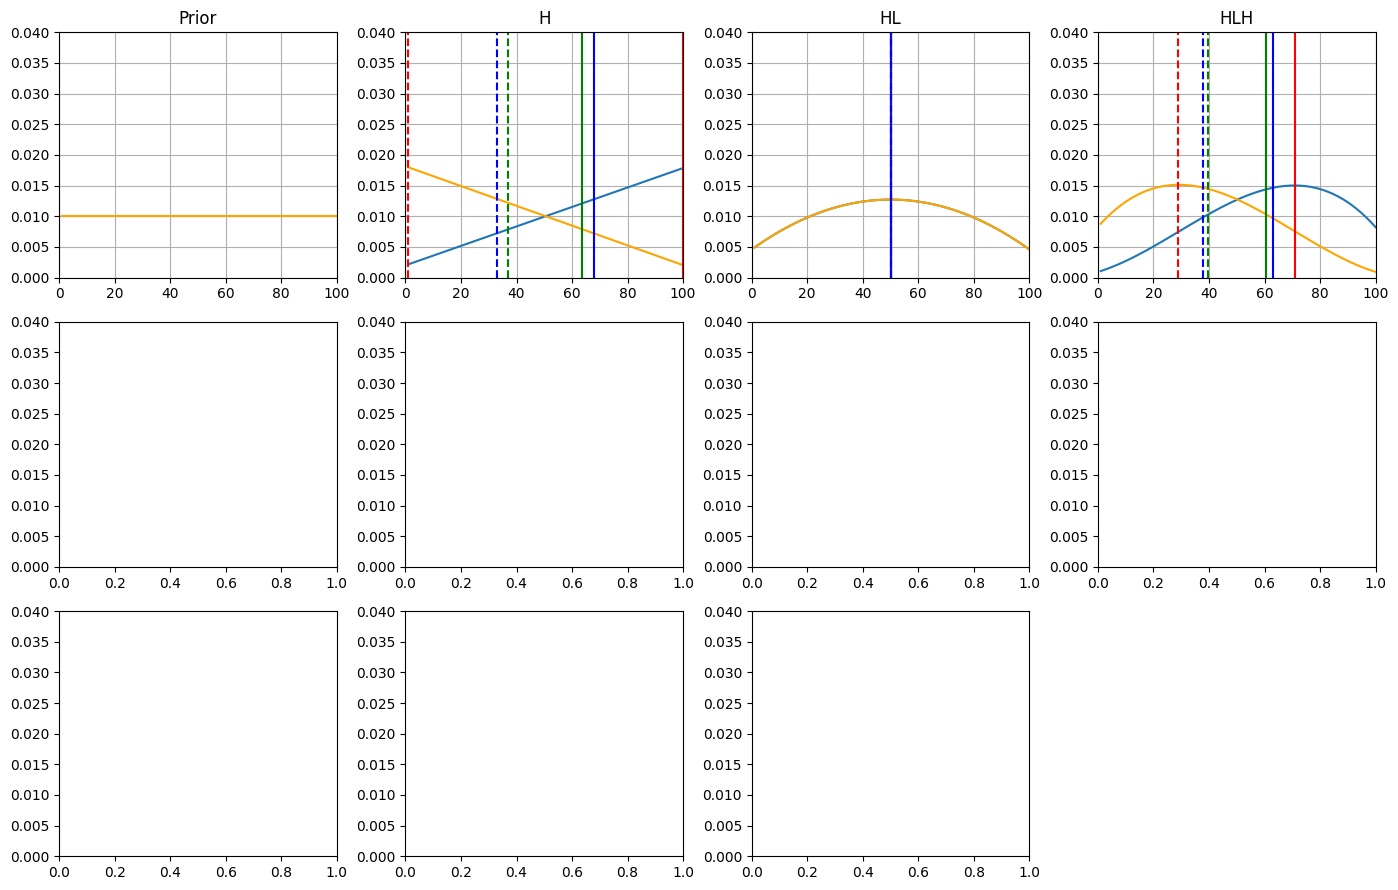

In [96]:
import matplotlib.pyplot as plt

# ------------------------------------
# 3行×4列（12枚）
# ------------------------------------
fig, axes = plt.subplots(3, 4, figsize=(14, 9))

axes = axes.flat

# ==========
# Prior
# ==========

axes[0].plot(xs, ps)
axes[0].plot(xs2, ps2, color="orange")
axes[0].set_title("Prior")
axes[0].set_xlim(0, 100)
axes[0].grid(True)

# ==========
# Updateごとに描画
# ==========
history = ""

for i, outcome in enumerate(dataset):

    history += outcome

    suite.Update(outcome)
    suite2.Update(outcome)

    xs, ps = zip(*suite.Items())
    xs2, ps2 = zip(*suite2.Items())

    map1 = MAP(suite)
    mean1 = Mean(suite)
    med1 = Median(suite)

    map2 = MAP(suite2)
    mean2 = Mean(suite2)
    med2 = Median(suite2)

    axes[i+1].plot(xs, ps)
    axes[i+1].plot(xs2, ps2, color="orange")

    axes[i+1].axvline(MAP(suite), color="red")
    axes[i+1].axvline(Mean(suite), color="green")
    axes[i+1].axvline(Median(suite), color="blue")

    axes[i+1].axvline(MAP(suite2), color="red", linestyle="--")
    axes[i+1].axvline(Mean(suite2), color="green", linestyle="--")
    axes[i+1].axvline(Median(suite2), color="blue", linestyle="--")

    axes[i+1].set_title(history)
    axes[i+1].set_xlim(0, 100)
    axes[i+1].grid(True)

# 最後の1枚は空白
axes[-1].axis("off")

for ax in axes[:-1]:
    ax.set_ylim(0, 0.04)

plt.tight_layout()
plt.show()

In [104]:
# ======================
# 1. セットアップ
# ======================

posts = range(1, 101)

article = Article1(posts, y=0.1)
reviewer = Reviewer1(posts, y=0.9)

history = []

# ======================
# 2. 閉ループ更新
# ======================

for i in range(10):

    # ReviewerがArticleを見て評価
    # （ここでは簡略化して ArticleのMAPを観測データとする）
    observation = 'H' if MAP(article) > 50 else 'T'

    reviewer.Update(observation)

    # Reviewerの状態でArticleを更新（逆フィードバック）
    feedback = 'H' if MAP(reviewer) > 50 else 'T'

    article.Update(feedback)

    # 記録
    history.append((MAP(article), MAP(reviewer)))

    print(i, "Article MAP:", MAP(article), "Reviewer MAP:", MAP(reviewer))

0 Article MAP: 100 Reviewer MAP: 100
1 Article MAP: 50 Reviewer MAP: 50
2 Article MAP: 71 Reviewer MAP: 71
3 Article MAP: 50 Reviewer MAP: 50
4 Article MAP: 62 Reviewer MAP: 62
5 Article MAP: 50 Reviewer MAP: 50
6 Article MAP: 59 Reviewer MAP: 59
7 Article MAP: 50 Reviewer MAP: 50
8 Article MAP: 57 Reviewer MAP: 57
9 Article MAP: 50 Reviewer MAP: 50


In [105]:
article = Article1(range(1,101), y=0.1)
reviewer = Reviewer1(range(1,101), y=0.9)

print("before:", MAP(article), MAP(reviewer))

article.Update('H')

print("after article:", MAP(article))
print("reviewer unchanged:", MAP(reviewer))

before: 1 1
after article: 100
reviewer unchanged: 1


In [106]:
posts = range(1, 101)

article = Article1(posts, y=0.1)
reviewer = Reviewer1(posts, y=0.9)

for i in range(10):

    # Reviewerの状態から観測を作る
    obs = 'H' if MAP(reviewer) > 50 else 'T'

    # Articleだけ更新
    article.Update(obs)

    print(i, "Article MAP:", MAP(article))

0 Article MAP: 1
1 Article MAP: 1
2 Article MAP: 1
3 Article MAP: 1
4 Article MAP: 1
5 Article MAP: 1
6 Article MAP: 1
7 Article MAP: 1
8 Article MAP: 1
9 Article MAP: 1


In [107]:
posts = range(1, 101)

article = Article1(posts, y=0.1)
reviewer = Reviewer1(posts, y=0.9)

history_a = []
history_r = []

for i in range(20):

    # Article → Reviewer
    obs_r = 'H' if MAP(article) > 50 else 'T'
    reviewer.Update(obs_r)

    # Reviewer → Article
    obs_a = 'H' if MAP(reviewer) > 50 else 'T'
    article.Update(obs_a)

    history_a.append(MAP(article))
    history_r.append(MAP(reviewer))

    print(i, history_a[-1], history_r[-1])

0 100 100
1 50 50
2 71 71
3 50 50
4 62 62
5 50 50
6 59 59
7 50 50
8 57 57
9 50 50
10 56 56
11 50 50
12 55 55
13 50 50
14 54 54
15 50 50
16 54 54
17 50 50
18 53 53
19 50 50


0 100 100
1 50 50
2 71 71
3 50 50
4 62 62
5 50 50
6 59 59
7 50 50
8 57 57
9 50 50
10 56 56
11 50 50
12 55 55
13 50 50
14 54 54
15 50 50
16 54 54
17 50 50
18 53 53
19 50 50


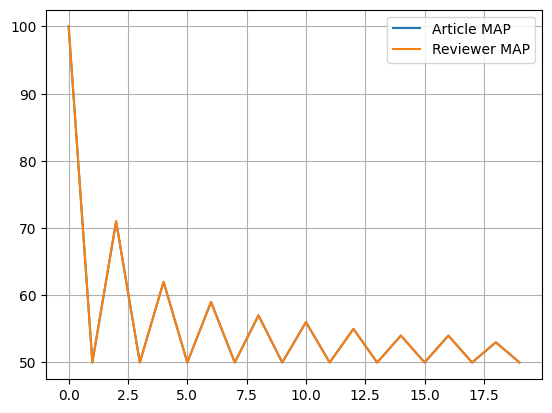

In [108]:
import matplotlib.pyplot as plt

# =====================
# 初期化
# =====================
posts = range(1, 101)

article = Article1(posts, y=0.1)
reviewer = Reviewer1(posts, y=0.9)

history_article = []
history_reviewer = []

# =====================
# 閉ループ更新
# =====================
for i in range(20):

    # 観測（適当にMAPで作る簡略モデル）
    obs_a = 'H' if MAP(article) > 50 else 'T'
    reviewer.Update(obs_a)

    obs_r = 'H' if MAP(reviewer) > 50 else 'T'
    article.Update(obs_r)

    # MAP記録
    history_article.append(MAP(article))
    history_reviewer.append(MAP(reviewer))

    print(i, history_article[-1], history_reviewer[-1])





# =====================
# グラフ
# =====================
plt.plot(history_article, label="Article MAP")
plt.plot(history_reviewer, label="Reviewer MAP")
plt.legend()
plt.grid()
plt.show()

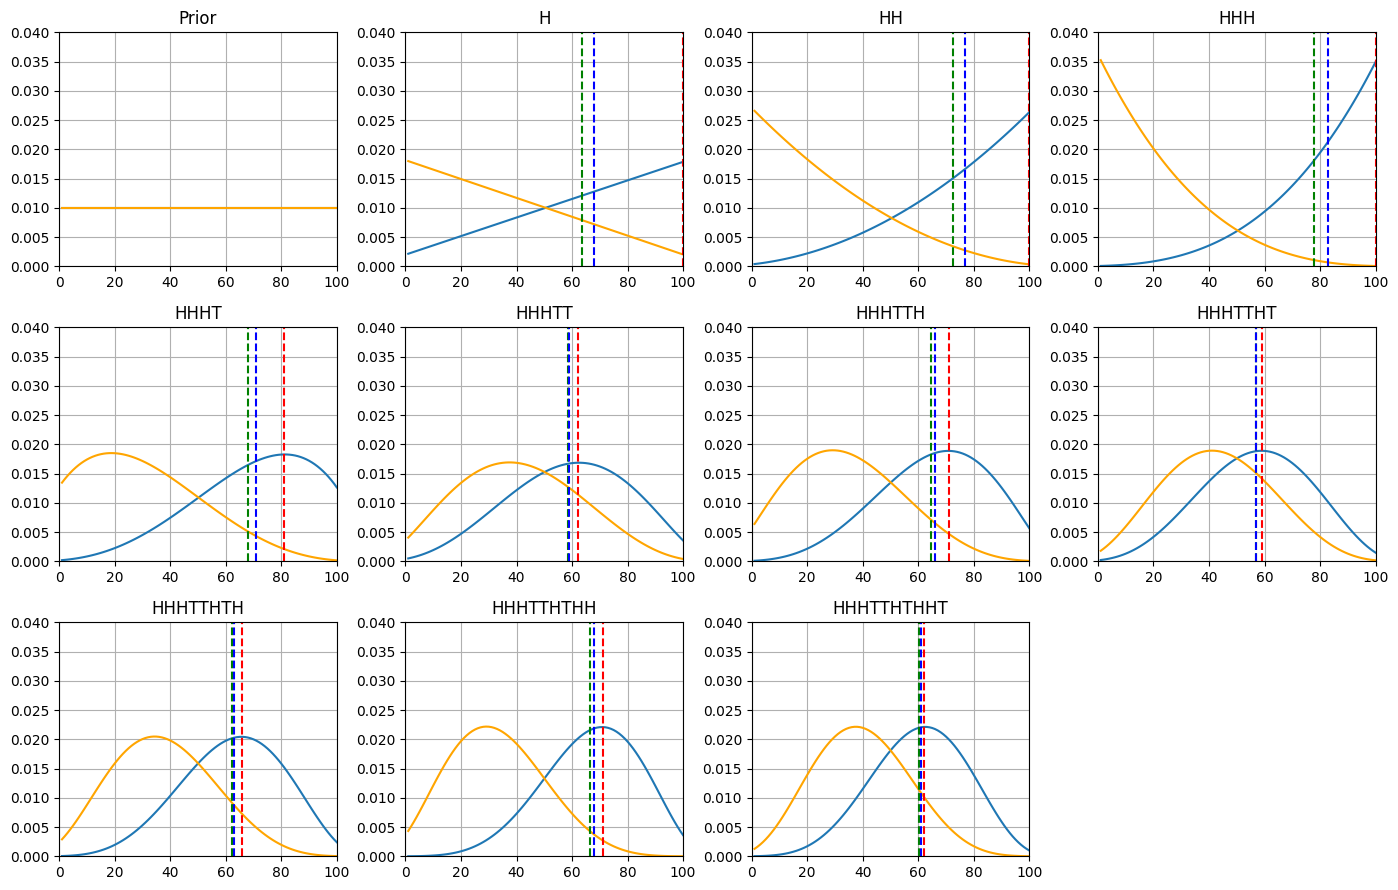

In [109]:
import matplotlib.pyplot as plt

# =========================
# MAP / Mean / Median
# =========================

def MAP(suite):
    return max(suite.Items(), key=lambda x: x[1])[0]

def Mean(suite):
    return sum(x * p for x, p in suite.Items()) / sum(p for _, p in suite.Items())

def Median(suite):
    total = 0
    for x, p in sorted(suite.Items()):
        total += p
        if total >= 0.5:
            return x

# =========================
# 初期設定
# =========================

posts = range(1, 101)

suite = Article1(posts, y=0.1)
suite2 = Reviewer1(posts, y=0.9)

# 例：観測データ
dataset = list("HHHTTHTHHT")  # 好きに変更OK

# =========================
# 図（3×4）
# =========================

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
axes = axes.flatten()

# =========================
# Prior
# =========================

xs, ps = zip(*suite.Items())
xs2, ps2 = zip(*suite2.Items())

axes[0].plot(xs, ps)
axes[0].plot(xs2, ps2, color="orange")
axes[0].set_title("Prior")
axes[0].set_xlim(0, 100)
axes[0].grid(True)
axes[0].set_ylim(0, 0.04)

# =========================
# Updateごとのギザギザ
# =========================

history = ""

for i, outcome in enumerate(dataset):

    history += outcome

    suite.Update(outcome)
    suite2.Update(outcome)

    xs, ps = zip(*suite.Items())
    xs2, ps2 = zip(*suite2.Items())

    # --- 統計量 ---
    m = Mean(suite)
    med = Median(suite)
    mapv = MAP(suite)

    # --- プロット ---
    ax = axes[i + 1]

    ax.plot(xs, ps)
    ax.plot(xs2, ps2, color="orange")

    # MAP / Mean / Median を縦線で追加
    ax.axvline(m, color="green", linestyle="--", label="Mean")
    ax.axvline(med, color="blue", linestyle="--", label="Median")
    ax.axvline(mapv, color="red", linestyle="--", label="MAP")

    ax.set_title(history)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 0.04)
    ax.grid(True)

# =========================
# 最後の空白
# =========================

axes[-1].axis("off")

plt.tight_layout()
plt.show()